# Unidade 5 — KPIs de Acidentes Fatais da PRF 2025

Este notebook apresenta a análise de acidentes registrados pela Polícia Rodoviária Federal (PRF) em 2025, com foco na variável `acidente_fatal`.

O objetivo é desenvolver cinco KPIs que permitam identificar padrões e fatores associados à ocorrência de acidentes fatais.

As análises são realizadas a partir da base de dados tratada na Unidade 4, utilizando Python e Pandas para manipulação dos dados e Matplotlib para visualização dos resultados.

##  Importação e carregamento dos dados

Nesta etapa, são importadas as bibliotecas necessárias para a análise e carregada a base de dados tratada.

O parâmetro `sep=";"` informa ao Pandas que os campos do arquivo CSV são separados por ponto e vírgula.

In [5]:
import pandas as pd

df = pd.read_csv(
    "../Unidade 4/dados_tratados/base_analitica_prf_2025.csv",
    sep=";"
)

df.head()

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,fim_de_semana,hora,turno,faixa_horaria,acidente_fatal,total_vitimas,acidente_grave,indice_gravidade,br_formatada,chave_localidade
0,652493,2025-01-01,QUARTA-FEIRA,06:20:00,SP,116,225.0,GUARULHOS,REAÇÃO TARDIA OU INEFICIENTE DO CONDUTOR,TOMBAMENTO,...,0,6,MANHA,06H-08H,0,1,0,1,BR-116,SP_GUARULHOS_BR-116
1,652519,2025-01-01,QUARTA-FEIRA,07:50:00,CE,116,NaN,PENAFORTE,PISTA ESBURACADA,COLISÃO FRONTAL,...,0,7,MANHA,06H-08H,1,2,1,4,BR-116,CE_PENAFORTE_BR-116
2,652522,2025-01-01,QUARTA-FEIRA,08:45:00,PR,369,NaN,CORNELIO PROCOPIO,REAÇÃO TARDIA OU INEFICIENTE DO CONDUTOR,COLISÃO TRASEIRA,...,0,8,MANHA,06H-08H,0,3,0,3,BR-369,PR_CORNELIO PROCOPIO_BR-369
3,652544,2025-01-01,QUARTA-FEIRA,11:00:00,PR,116,74.0,CAMPINA GRANDE DO SUL,REAÇÃO TARDIA OU INEFICIENTE DO CONDUTOR,SAÍDA DE LEITO CARROÇÁVEL,...,0,11,MANHA,09H-11H,0,1,0,1,BR-116,PR_CAMPINA GRANDE DO SUL_BR-116
4,652549,2025-01-01,QUARTA-FEIRA,09:30:00,MG,251,471.0,FRANCISCO SA,VELOCIDADE INCOMPATÍVEL,COLISÃO FRONTAL,...,0,9,MANHA,09H-11H,0,2,1,3,BR-251,MG_FRANCISCO SA_BR-251


### `df.info()`

Exibe informações gerais sobre a estrutura da base de dados, incluindo a quantidade de registros, as colunas existentes, os valores não nulos e os tipos de dados de cada variável.

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 72529 entries, 0 to 72528
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      72529 non-null  int64  
 1   data_inversa            72529 non-null  str    
 2   dia_semana              72529 non-null  str    
 3   horario                 72529 non-null  str    
 4   uf                      72529 non-null  str    
 5   br                      72529 non-null  int64  
 6   km                      45854 non-null  float64
 7   municipio               72529 non-null  str    
 8   causa_acidente          72529 non-null  str    
 9   tipo_acidente           72529 non-null  str    
 10  classificacao_acidente  72529 non-null  str    
 11  fase_dia                72529 non-null  str    
 12  sentido_via             72529 non-null  str    
 13  condicao_metereologica  72529 non-null  str    
 14  tipo_pista              72529 non-null  str    
 

### `df.columns.tolist()`

Retorna os nomes de todas as colunas do DataFrame em formato de lista, permitindo identificar e conferir as variáveis disponíveis na base de dados.

In [6]:
df.columns.tolist()

['id',
 'data_inversa',
 'dia_semana',
 'horario',
 'uf',
 'br',
 'km',
 'municipio',
 'causa_acidente',
 'tipo_acidente',
 'classificacao_acidente',
 'fase_dia',
 'sentido_via',
 'condicao_metereologica',
 'tipo_pista',
 'tracado_via',
 'uso_solo',
 'pessoas',
 'mortos',
 'feridos_leves',
 'feridos_graves',
 'ilesos',
 'ignorados',
 'feridos',
 'veiculos',
 'latitude',
 'longitude',
 'regional',
 'delegacia',
 'uop',
 'ano',
 'mes',
 'trimestre',
 'dia_semana_num',
 'fim_de_semana',
 'hora',
 'turno',
 'faixa_horaria',
 'acidente_fatal',
 'total_vitimas',
 'acidente_grave',
 'indice_gravidade',
 'br_formatada',
 'chave_localidade']

## KPI 1 — Percentual de acidentes fatais por tipo de acidente

Este KPI analisa a ocorrência de acidentes fatais de acordo com o tipo de acidente.

São calculados o total de acidentes, a quantidade de acidentes fatais e o percentual de fatalidade para cada tipo de acidente.

**Cálculo:**

Percentual de fatalidade = (Acidentes fatais ÷ Total de acidentes) × 100

A análise permite identificar quais tipos de acidentes apresentam maior proporção de ocorrências fatais.

In [8]:
kpi1 = (
    df.groupby("tipo_acidente")["acidente_fatal"]
    .agg(
        total_acidentes="count",
        acidentes_fatais="sum"
    )
    .reset_index()
)

kpi1["percentual_fatalidade"] = (
    kpi1["acidentes_fatais"] / kpi1["total_acidentes"] * 100
)

kpi1 = kpi1.sort_values(
    "percentual_fatalidade",
    ascending=False
)

kpi1

,tipo_acidente,total_acidentes,acidentes_fatais,percentual_fatalidade
1,ATROPELAMENTO DE PEDESTRE,3057,902,29.506052
4,COLISÃO FRONTAL,4739,1396,29.457691
6,COLISÃO LATERAL SENTIDO OPOSTO,2152,212,9.851301
11,EVENTOS ATÍPICOS,287,23,8.013937
0,ATROPELAMENTO DE ANIMAL,1133,68,6.001765
14,SAÍDA DE LEITO CARROÇÁVEL,10209,605,5.926144
3,COLISÃO COM OBJETO,5109,297,5.813271
2,CAPOTAMENTO,1373,63,4.588492
7,COLISÃO TRANSVERSAL,9306,427,4.588438
8,COLISÃO TRASEIRA,14360,619,4.310585


### Gráfico — Percentual de acidentes fatais por tipo de acidente

O gráfico apresenta a proporção de acidentes fatais para cada tipo de acidente, facilitando a comparação entre as diferentes categorias.

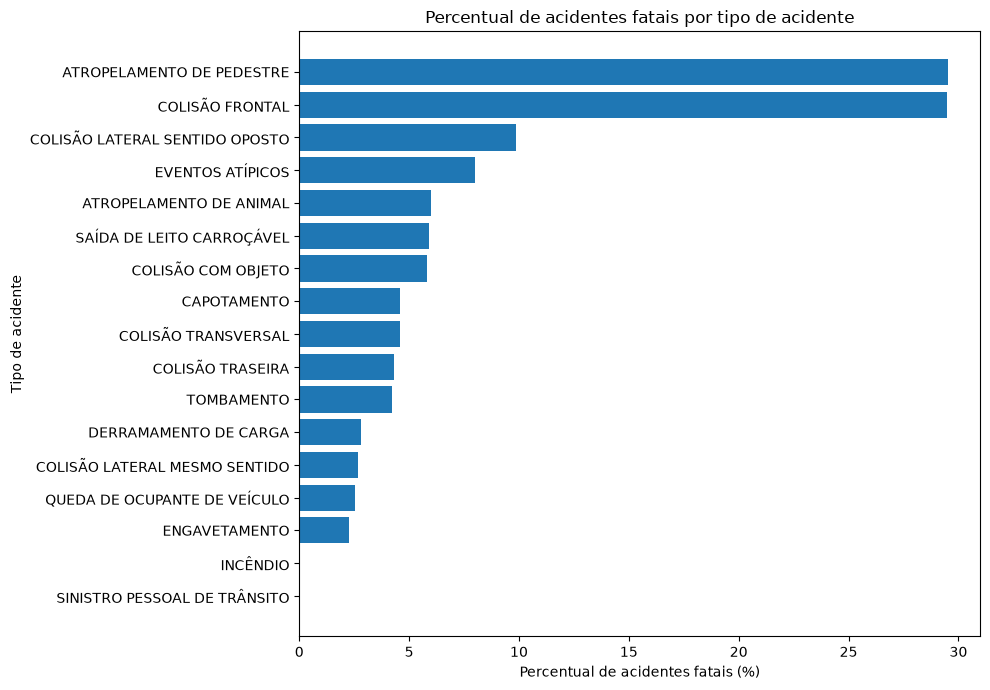

In [24]:
plt.figure(figsize=(10, 7))

plt.barh(
    kpi1["tipo_acidente"],
    kpi1["percentual_fatalidade"]
)

plt.xlabel("Percentual de acidentes fatais (%)")
plt.ylabel("Tipo de acidente")
plt.title("Percentual de acidentes fatais por tipo de acidente")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## KPI 2 — Percentual de acidentes fatais por tipo de pista

Este KPI analisa a ocorrência de acidentes fatais de acordo com o tipo de pista.

São calculados o total de acidentes, a quantidade de acidentes fatais e o percentual de fatalidade para cada tipo de pista.

**Cálculo:**

Percentual de fatalidade = (Acidentes fatais ÷ Total de acidentes) × 100

A análise permite identificar quais tipos de pista apresentam maior proporção de acidentes fatais.

In [10]:
kpi2 = (
    df.groupby("tipo_pista")["acidente_fatal"]
    .agg(
        total_acidentes="count",
        acidentes_fatais="sum"
    )
    .reset_index()
)

kpi2["percentual_fatalidade"] = (
    kpi2["acidentes_fatais"] / kpi2["total_acidentes"] * 100
)

kpi2 = kpi2.sort_values(
    "percentual_fatalidade",
    ascending=False
)

kpi2

,tipo_pista,total_acidentes,acidentes_fatais,percentual_fatalidade
2,SIMPLES,34733,3424,9.858060
0,DUPLA,30782,1501,4.876226
1,MÚLTIPLA,7014,285,4.063302


### Gráfico — Percentual de acidentes fatais por tipo de pista

O gráfico apresenta o percentual de acidentes fatais para cada tipo de pista, permitindo comparar as categorias e identificar aquelas com maior proporção de fatalidade.

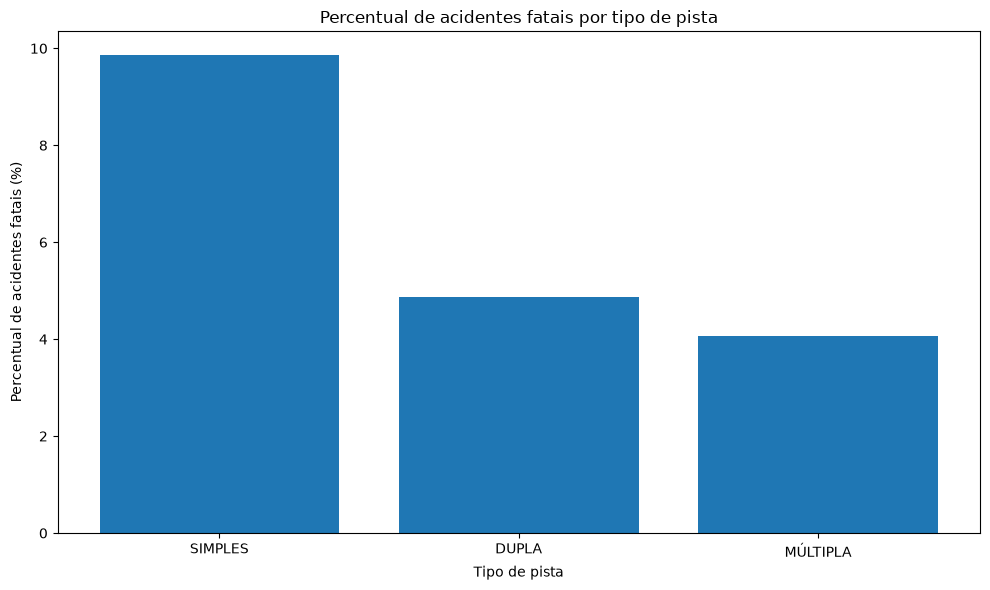

In [26]:
plt.figure(figsize=(10, 6))

plt.bar(
    kpi2["tipo_pista"],
    kpi2["percentual_fatalidade"]
)

plt.xlabel("Tipo de pista")
plt.ylabel("Percentual de acidentes fatais (%)")
plt.title("Percentual de acidentes fatais por tipo de pista")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## KPI 3 — Percentual de acidentes fatais por fase do dia

Este KPI analisa a ocorrência de acidentes fatais de acordo com a fase do dia.

São calculados o total de acidentes, a quantidade de acidentes fatais e o percentual de fatalidade para cada fase do dia.

**Cálculo:**

Percentual de fatalidade = (Acidentes fatais ÷ Total de acidentes) × 100

A análise permite identificar quais fases do dia apresentam maior proporção de acidentes fatais.

In [12]:
kpi3 = (
    df.groupby("fase_dia")["acidente_fatal"]
    .agg(
        total_acidentes="count",
        acidentes_fatais="sum"
    )
    .reset_index()
)

kpi3["percentual_fatalidade"] = (
    kpi3["acidentes_fatais"] / kpi3["total_acidentes"] * 100
)

kpi3 = kpi3.sort_values(
    "percentual_fatalidade",
    ascending=False
)

kpi3

,fase_dia,total_acidentes,acidentes_fatais,percentual_fatalidade
0,AMANHECER,3447,386,11.198143
2,PLENA NOITE,24781,2522,10.177152
1,ANOITECER,3926,253,6.444218
3,PLENO DIA,40375,2049,5.074923


### Gráfico — Percentual de acidentes fatais por fase do dia

O gráfico apresenta o percentual de acidentes fatais para cada fase do dia, permitindo comparar as categorias e identificar os períodos com maior proporção de fatalidade.

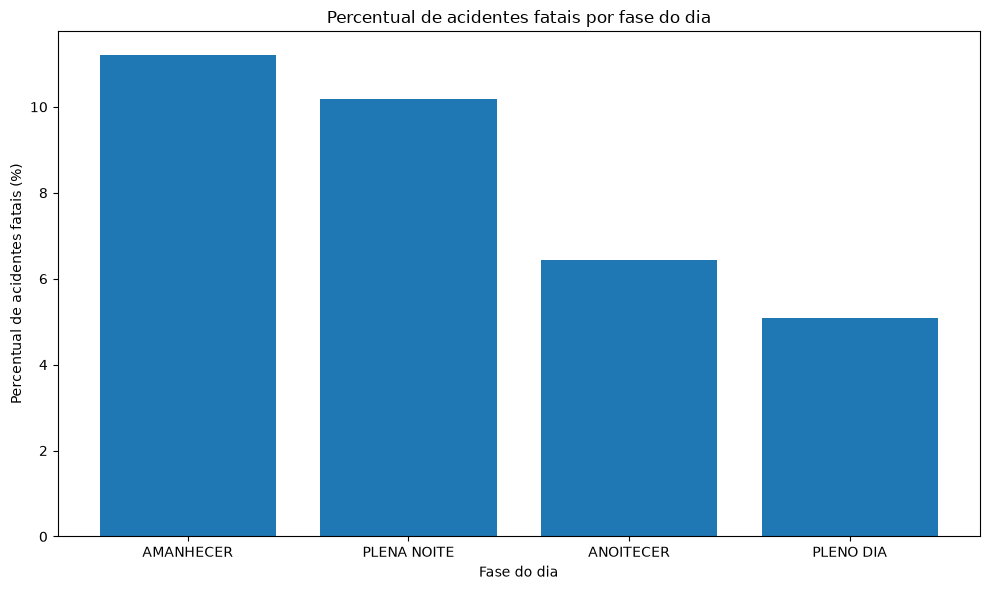

In [33]:
plt.figure(figsize=(10, 6))

plt.bar(
    kpi3["fase_dia"],
    kpi3["percentual_fatalidade"]
)

plt.xlabel("Fase do dia")
plt.ylabel("Percentual de acidentes fatais (%)")
plt.title("Percentual de acidentes fatais por fase do dia")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## KPI 4 — Percentual de acidentes fatais por condição meteorológica

Este KPI analisa a ocorrência de acidentes fatais de acordo com a condição meteorológica registrada no momento do acidente.

São calculados o total de acidentes, a quantidade de acidentes fatais e o percentual de fatalidade para cada condição meteorológica.

**Cálculo:**

Percentual de fatalidade = (Acidentes fatais ÷ Total de acidentes) × 100

A análise permite identificar quais condições meteorológicas apresentam maior proporção de acidentes fatais.

In [14]:
kpi4 = (
    df.groupby("condicao_metereologica")["acidente_fatal"]
    .agg(
        total_acidentes="count",
        acidentes_fatais="sum"
    )
    .reset_index()
)

kpi4["percentual_fatalidade"] = (
    kpi4["acidentes_fatais"] / kpi4["total_acidentes"] * 100
)

kpi4 = kpi4.sort_values(
    "percentual_fatalidade",
    ascending=False
)

kpi4

,condicao_metereologica,total_acidentes,acidentes_fatais,percentual_fatalidade
5,NEVOEIRO/NEBLINA,553,60,10.849910
3,IGNORADO,1000,99,9.900000
8,VENTO,104,9,8.653846
1,CÉU CLARO,46375,3419,7.372507
6,NUBLADO,11435,830,7.258417
0,CHUVA,6438,402,6.244175
2,GAROA/CHUVISCO,2422,144,5.945500
7,SOL,4201,247,5.879552
4,NEVE,1,0,0.000000


### Gráfico — Percentual de acidentes fatais por condição meteorológica

O gráfico apresenta o percentual de acidentes fatais para cada condição meteorológica, permitindo comparar as categorias e identificar aquelas que apresentam maior proporção de fatalidade.

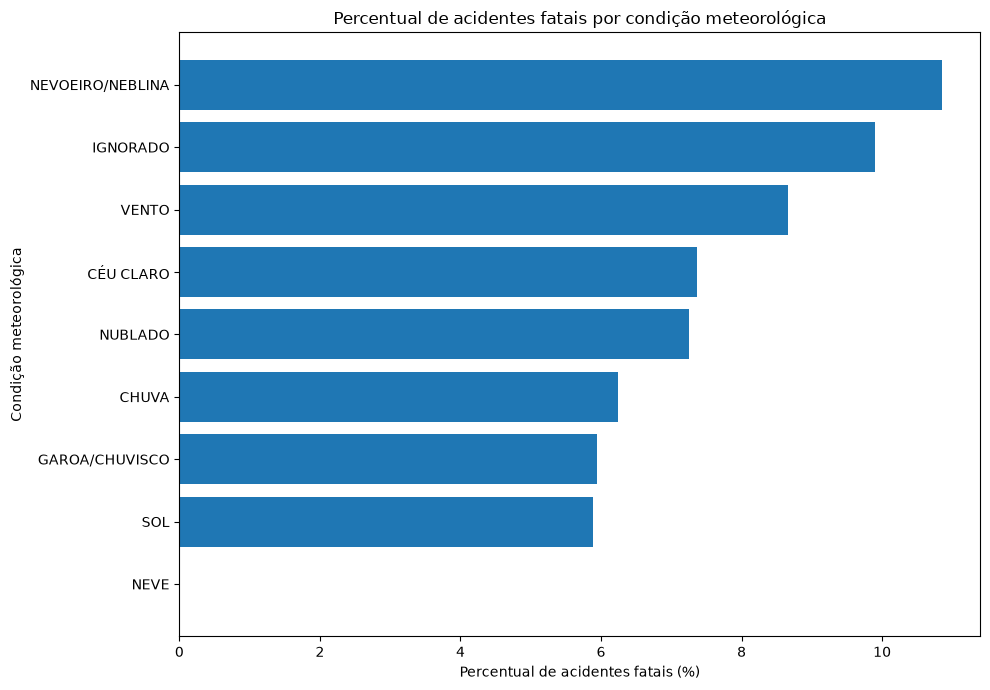

In [34]:
plt.figure(figsize=(10, 7))

plt.barh(
    kpi4["condicao_metereologica"],
    kpi4["percentual_fatalidade"]
)

plt.xlabel("Percentual de acidentes fatais (%)")
plt.ylabel("Condição meteorológica")
plt.title("Percentual de acidentes fatais por condição meteorológica")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## KPI 5 — Acidentes fatais por UF e BR

Este KPI analisa a distribuição dos acidentes fatais por Unidade Federativa (UF) e rodovia (BR).

A análise permite identificar as rodovias que concentram a maior quantidade de acidentes fatais e, consequentemente, destacar as vias que merecem maior atenção na análise de segurança viária.

**Cálculo:**

Total de acidentes fatais = soma da variável `acidente_fatal`

A análise considera a combinação entre `uf` e `br`, permitindo identificar as rodovias com maior número de acidentes fatais.

In [37]:
kpi5 = (
    df.groupby(["uf", "br"])["acidente_fatal"]
    .agg(
        total_acidentes="count",
        acidentes_fatais="sum"
    )
    .reset_index()
)

kpi5 = kpi5.sort_values(
    "acidentes_fatais",
    ascending=False
)

kpi5.head(10)

,uf,br,total_acidentes,acidentes_fatais
243,SP,116,3249,143
228,SC,101,4222,140
97,MG,381,2845,139
167,PR,277,2157,134
178,RJ,101,2415,125
84,MG,40,1972,123
21,BA,101,956,122
55,ES,101,2084,112
23,BA,116,1038,110
171,PR,376,1700,109


### Gráfico — 5 rodovias com maior quantidade de acidentes fatais

O gráfico apresenta as cinco combinações de UF e BR com maior quantidade de acidentes fatais registradas na base da PRF em 2025.

A análise permite identificar as rodovias que concentram o maior número absoluto de acidentes fatais.

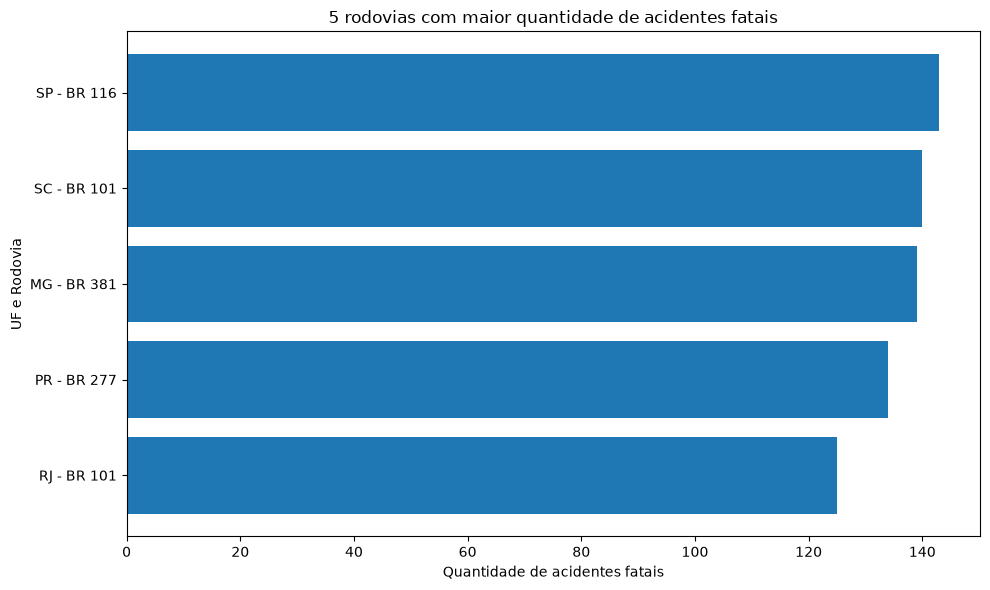

In [38]:
top5_kpi5 = kpi5.head(5).copy()

top5_kpi5["uf_br"] = (
    top5_kpi5["uf"].astype(str)
    + " - BR "
    + top5_kpi5["br"].astype(str)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top5_kpi5["uf_br"],
    top5_kpi5["acidentes_fatais"]
)

plt.xlabel("Quantidade de acidentes fatais")
plt.ylabel("UF e Rodovia")
plt.title("5 rodovias com maior quantidade de acidentes fatais")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [23]:
kpi5.head(5)

,uf,br,total_acidentes,acidentes_fatais
243,SP,116,3249,143
228,SC,101,4222,140
97,MG,381,2845,139
167,PR,277,2157,134
178,RJ,101,2415,125
